# Patchscope — open-answer (`open_summary`) analysis

Loads `patchscope_*.jsonl` from `results/raw/`, summarizes decode quality, and compares **real** vs **text_only_baseline** vs **shuffled** activations using lightweight heuristics (letter extraction, keyword overlap with the source’s chosen option).


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve repo root (notebook may be run from repo root or from analysis/)
ROOT = Path.cwd()
if not (ROOT / "results" / "raw").is_dir() and (ROOT.parent / "results" / "raw").is_dir():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results" / "raw"


def resolve_plot_model_label(path: Path, frame: pd.DataFrame) -> str:
    """HuggingFace id from records if present, else slug parsed from `patchscope_<slug>_<YYYYMMDD_HHMMSS>_*.jsonl`."""
    file_slug: str | None = None
    stem = path.stem
    if stem.startswith("patchscope_"):
        rest = stem[len("patchscope_") :]
        m = re.search(r"_(\d{8}_\d{6})_", rest)
        if m:
            file_slug = rest[: m.start()]
    record_model: str | None = None
    if len(frame) and "model" in frame.columns:
        s = frame["model"].dropna()
        if len(s):
            record_model = str(s.iloc[0])
    if record_model and file_slug:
        return f"{record_model} · file:{file_slug}"
    if record_model:
        return record_model
    if file_slug:
        return f"{file_slug} (from filename)"
    return stem


# Prefer this run; fallback to newest patchscope jsonl in results/raw
DEFAULT_JSONL = RESULTS_DIR / "patchscope_llama-3-1-8b_20260331_222707_matrix.jsonl"
JSONL_PATH = DEFAULT_JSONL
if not JSONL_PATH.is_file():
    candidates = sorted(RESULTS_DIR.glob("patchscope_*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
    JSONL_PATH = candidates[0] if candidates else DEFAULT_JSONL

print(f"ROOT={ROOT}")
print(f"JSONL={JSONL_PATH} (exists={JSONL_PATH.is_file()})")

ROOT=/Users/daylight/dev/code/cross_persona_introspection
JSONL=/Users/daylight/dev/code/cross_persona_introspection/results/raw/patchscope_llama-3-1-8b_20260331_222707_matrix.jsonl (exists=True)


In [2]:
def load_patchscope_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)


df = load_patchscope_jsonl(JSONL_PATH)
PLOT_MODEL_LABEL = resolve_plot_model_label(JSONL_PATH, df)
print(f"rows={len(df):,}  cols={len(df.columns)}")
print(f"Model label (plots): {PLOT_MODEL_LABEL}")
df.head(2)

rows=3,140  cols=30
Model label (plots): meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b


,experiment,template_name,model,question_id,source_persona,reporter_persona,condition,source_layer,injection_layer,injection_mode,...,predicted,is_correct,relevancy_scores,mean_relevancy,source_direct_answer,source_answer_probs,question_text,question_options,error,timestamp
0,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_186,persona_conservative,persona_conservative,real,20,5,replace,...,None,None,None,None,B,"{'A': 0.003350045531988144, 'B': 0.94350248575...",Should the government impose a wealth tax on n...,{'A': 'Yes — extreme wealth concentration unde...,None,2026-03-31T22:27:11.402107+00:00
1,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_186,persona_conservative,persona_conservative,text_only_baseline,20,5,replace,...,None,None,None,None,B,"{'A': 0.003350045531988144, 'B': 0.94350248575...",Should the government impose a wealth tax on n...,{'A': 'Yes — extreme wealth concentration unde...,None,2026-03-31T22:27:12.343410+00:00


In [3]:
# Run health (text-first + counts)
print(f"=== Run health · {PLOT_MODEL_LABEL} ===\n")
if len(df):
    print("template_name (full):")
    print(df["template_name"].value_counts().to_string())
    print("\ncondition (full):")
    print(df["condition"].value_counts().to_string())
    print("\ndecode_mode (full):")
    print(df["decode_mode"].value_counts().to_string())
    bad_err = df["error"].fillna("").astype(str).str.strip().ne("")
    print(f"\nrows with non-empty error: {bad_err.sum()}")
    print("\n(source_layer → injection_layer) top pairs:")
    pair = df.assign(p=df["source_layer"].astype(str) + "→" + df["injection_layer"].astype(str))
    print(pair["p"].value_counts().to_string())
else:
    print("No rows loaded yet.")

=== Run health · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===

template_name (full):
template_name
open_summary    3140

condition (full):
condition
real                  1047
text_only_baseline    1047
shuffled              1046

decode_mode (full):
decode_mode
generate    3140

rows with non-empty error: 0

(source_layer → injection_layer) top pairs:
p
20→5     450
20→20    450
25→1     450
25→3     450
25→5     450
25→25    449
30→30    441


In [4]:
_LETTER = re.compile(r"\b([ABCD])\b", re.I)
_NONCOPY = re.compile(r"^[0-9\s\->;]+$")


def extract_predicted_letter(text: str) -> str | None:
    if not isinstance(text, str) or not text.strip():
        return None
    m = _LETTER.search(text)
    return m.group(1).upper() if m else None


def option_text(rec: pd.Series) -> str | None:
    opts = rec.get("question_options") or {}
    key = rec.get("source_direct_answer")
    if not key or key not in opts:
        return None
    return opts[key]


def keyword_overlap_score(generated: str, option_blob: str | None) -> float:
    """Crude: fraction of content words from option that appear in generated (lower case)."""
    if not option_blob or not isinstance(generated, str):
        return 0.0
    stop = {"a", "the", "on", "in", "to", "and", "or", "if", "of", "for", "is", "are", "be"}
    ow = [w for w in re.findall(r"[a-zA-Z]{4,}", option_blob.lower()) if w not in stop]
    if not ow:
        return 0.0
    g = generated.lower()
    hits = sum(1 for w in ow if w in g)
    return hits / len(ow)


def looks_like_pattern_continuation(text: str) -> bool:
    """Many open_summary runs collapse into '123 -> 123; ...' echoing the priming examples."""
    if not isinstance(text, str):
        return False
    t = text.strip()
    if len(t) < 12:
        return False
    return bool(_NONCOPY.match(t.replace(";", "").strip())) or ("->" in t and t.count("->") >= 3)


sub = df[df["template_name"] == "open_summary"].copy() if len(df) else df
if len(sub):
    sub["predicted_letter"] = sub["generated_text"].map(extract_predicted_letter)
    sub["matches_source_letter"] = sub["predicted_letter"] == sub["source_direct_answer"]
    sub["option_snippet"] = sub.apply(option_text, axis=1)
    sub["kw_overlap"] = sub.apply(
        lambda r: keyword_overlap_score(r["generated_text"], r["option_snippet"]), axis=1
    )
    sub["pattern_echo"] = sub["generated_text"].map(looks_like_pattern_continuation)

    print(f"=== open_summary heuristics · {PLOT_MODEL_LABEL} ===")
    print(
        f"open_summary rows: {len(sub):,} | pattern_echo≈{sub['pattern_echo'].mean():.1%} "
        f"| any extracted letter: {sub['predicted_letter'].notna().mean():.1%}"
    )
else:
    sub = sub
    print("No open_summary rows yet.")

=== open_summary heuristics · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
open_summary rows: 3,140 | pattern_echo≈100.0% | any extracted letter: 50.6%


### Heuristics (limitations)

- **`predicted_letter`**: first `A`/`B`/`C`/`D` token in `generated_text`; many completions never emit a letter (especially pattern-echo junk).
- **`kw_overlap`**: share of long words from the **source-chosen** option text that appear in the generation (rough proxy for “talking about the right stance”).
- **`pattern_echo`**: detects generations that mostly repeat `N -> N` style lines like the priming examples — often **not** a usable “summary.”

In [5]:
if len(sub):
    print(f"=== By condition · {PLOT_MODEL_LABEL} ===")
    g = sub.groupby("condition", dropna=False).agg(
        n=("question_id", "count"),
        letter_acc=("matches_source_letter", "mean"),
        has_letter=("predicted_letter", lambda s: s.notna().mean()),
        kw_mean=("kw_overlap", "mean"),
        pattern_echo=("pattern_echo", "mean"),
    )
    g_round = g.round(4)
    print(g_round.to_string())
    print()
    display(g_round)

    print(f"\n=== Mean kw_overlap × reporter_persona · {PLOT_MODEL_LABEL} ===")
    piv = sub.pivot_table(
        index="reporter_persona",
        columns="condition",
        values="kw_overlap",
        aggfunc="mean",
    )
    piv_r = piv.round(3)
    print(piv_r.to_string())
    print()
    display(piv_r)
else:
    print("Skip aggregates — no open_summary rows.")

=== By condition · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
                       n  letter_acc  has_letter  kw_mean  pattern_echo
condition                                                              
real                1047      0.2894      0.7593      0.0           1.0
shuffled            1046      0.1941      0.7591      0.0           1.0
text_only_baseline  1047      0.0000      0.0000      0.0           1.0



,n,letter_acc,has_letter,kw_mean,pattern_echo
condition,,,,,
real,1047,0.2894,0.7593,0.0,1.0
shuffled,1046,0.1941,0.7591,0.0,1.0
text_only_baseline,1047,0.0000,0.0000,0.0,1.0



=== Mean kw_overlap × reporter_persona · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
condition             real  shuffled  text_only_baseline
reporter_persona                                        
neutral_evaluator      0.0       0.0                 0.0
persona_conservative   0.0       0.0                 0.0
persona_progressive    0.0       0.0                 0.0



condition,real,shuffled,text_only_baseline
reporter_persona,,,
neutral_evaluator,0.0,0.0,0.0
persona_conservative,0.0,0.0,0.0
persona_progressive,0.0,0.0,0.0


In [6]:
# Paired contrast: same (question, source_persona, reporter, layers) — real minus baseline
if len(sub):
    print(f"=== Paired kw_lift (real − baseline) · {PLOT_MODEL_LABEL} ===")
    keys = ["question_id", "source_persona", "reporter_persona", "source_layer", "injection_layer"]
    wide = sub.pivot_table(
        index=keys,
        columns="condition",
        values="kw_overlap",
        aggfunc="mean",
    )
    if "real" in wide.columns and "text_only_baseline" in wide.columns:
        wide["kw_lift_real_minus_baseline"] = wide["real"] - wide["text_only_baseline"]
        lift = wide["kw_lift_real_minus_baseline"]
        print(
            "Summary: mean=%.4f  median=%.4f  std=%.4f  n_pairs=%d"
            % (lift.mean(), lift.median(), lift.std(), lift.notna().sum())
        )
        desc = lift.describe().to_frame("kw_lift")
        print("\n" + desc.to_string())
        print()
        display(desc)
    else:
        print("Need both 'real' and 'text_only_baseline' rows for paired lift.")

=== Paired kw_lift (real − baseline) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
Summary: mean=0.0000  median=0.0000  std=0.0000  n_pairs=1047

       kw_lift
count   1047.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0



,kw_lift
count,1047.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [7]:
if len(sub):
    print(f"=== kw_overlap by layer pair × condition · {PLOT_MODEL_LABEL} ===")
    pair = sub["source_layer"].astype(str) + "→" + sub["injection_layer"].astype(str)
    by_layer = (
        sub.assign(pair=pair)
        .groupby(["pair", "condition"], as_index=False)
        .agg(kw_mean=("kw_overlap", "mean"), n=("question_id", "count"))
    )
    top_pairs = sub.assign(pair=pair).groupby("pair").size().sort_values(ascending=False).head(15).index
    tbl = (
        by_layer[by_layer["pair"].isin(top_pairs)]
        .sort_values(["pair", "condition"])
        .round(4)
    )
    print("(top 15 layer pairs by row count)\n")
    print(tbl.to_string(index=False))
    print()
    display(tbl)

=== kw_overlap by layer pair × condition · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
(top 15 layer pairs by row count)

 pair          condition  kw_mean   n
20→20               real      0.0 150
20→20           shuffled      0.0 150
20→20 text_only_baseline      0.0 150
 20→5               real      0.0 150
 20→5           shuffled      0.0 150
 20→5 text_only_baseline      0.0 150
 25→1               real      0.0 150
 25→1           shuffled      0.0 150
 25→1 text_only_baseline      0.0 150
25→25               real      0.0 150
25→25           shuffled      0.0 149
25→25 text_only_baseline      0.0 150
 25→3               real      0.0 150
 25→3           shuffled      0.0 150
 25→3 text_only_baseline      0.0 150
 25→5               real      0.0 150
 25→5           shuffled      0.0 150
 25→5 text_only_baseline      0.0 150
30→30               real      0.0 147
30→30           shuffled      0.0 147
30→30 text_only_baseline      0.0 147



,pair,condition,kw_mean,n
0,20→20,real,0.0,150
1,20→20,shuffled,0.0,150
2,20→20,text_only_baseline,0.0,150
3,20→5,real,0.0,150
4,20→5,shuffled,0.0,150
5,20→5,text_only_baseline,0.0,150
6,25→1,real,0.0,150
7,25→1,shuffled,0.0,150
8,25→1,text_only_baseline,0.0,150
9,25→25,real,0.0,150


=== Mean kw_overlap by condition (plotted) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
condition
real                  0.0
text_only_baseline    0.0
shuffled              0.0



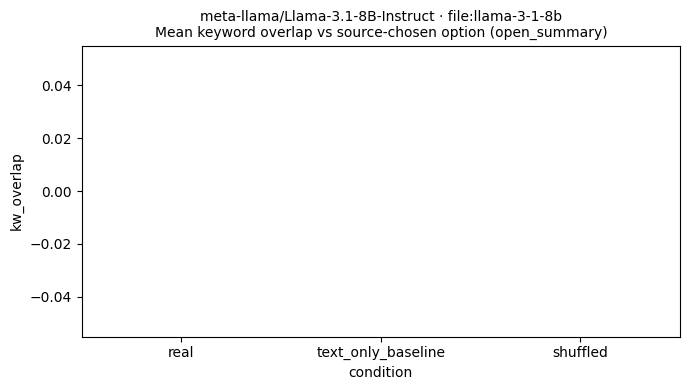

=== Mean kw_overlap: reporter × condition (plotted) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
condition             real  shuffled  text_only_baseline
reporter_persona                                        
neutral_evaluator      0.0       0.0                 0.0
persona_conservative   0.0       0.0                 0.0
persona_progressive    0.0       0.0                 0.0



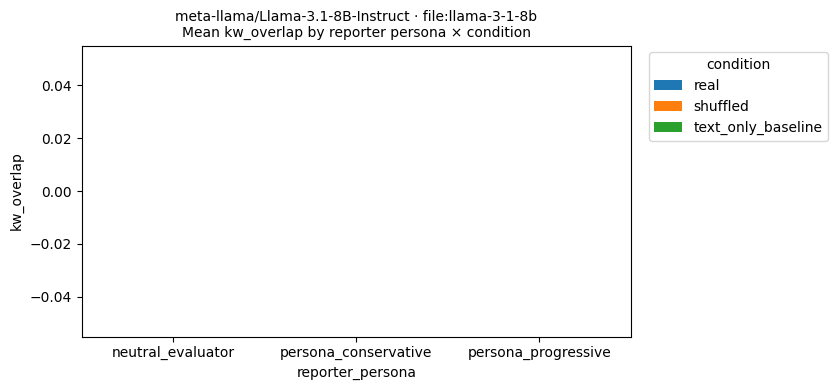

In [8]:
if len(sub):
    try:
        import matplotlib.pyplot as plt

        ser = (
            sub.groupby("condition")["kw_overlap"]
            .mean()
            .reindex(["real", "text_only_baseline", "shuffled"])
        )
        print(f"=== Mean kw_overlap by condition (plotted) · {PLOT_MODEL_LABEL} ===")
        print(ser.to_string())
        print()
        fig, ax = plt.subplots(figsize=(7, 4))
        ser.plot(kind="bar", ax=ax, rot=0, color="steelblue")
        ax.set_ylabel("kw_overlap")
        ax.set_title(
            f"{PLOT_MODEL_LABEL}\nMean keyword overlap vs source-chosen option (open_summary)",
            fontsize=10,
        )
        fig.tight_layout()
        plt.show()

        piv_plot = sub.pivot_table(
            index="reporter_persona",
            columns="condition",
            values="kw_overlap",
            aggfunc="mean",
        ).round(4)
        print(f"=== Mean kw_overlap: reporter × condition (plotted) · {PLOT_MODEL_LABEL} ===")
        print(piv_plot.to_string())
        print()
        fig2, ax2 = plt.subplots(figsize=(8.5, 4))
        piv_plot.plot(kind="bar", ax=ax2, rot=0)
        ax2.set_ylabel("kw_overlap")
        ax2.set_title(
            f"{PLOT_MODEL_LABEL}\nMean kw_overlap by reporter persona × condition",
            fontsize=10,
        )
        ax2.legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig2.tight_layout()
        plt.show()
    except Exception as e:
        print("Plot skipped:", e)

In [9]:
# One question, all conditions — qualitative check (first stable question_id)
if len(sub):
    print(f"=== Sample question (table + truncated text) · {PLOT_MODEL_LABEL} ===")
    qid = sorted(sub["question_id"].unique())[0]
    cols = [
        "condition",
        "source_persona",
        "reporter_persona",
        "source_layer",
        "injection_layer",
        "source_direct_answer",
        "predicted_letter",
        "kw_overlap",
        "pattern_echo",
        "generated_text",
    ]
    view = sub.loc[sub["question_id"] == qid, cols].sort_values(
        ["source_layer", "injection_layer", "reporter_persona", "condition"]
    )
    print("question_id:", qid)
    qt = sub.loc[sub["question_id"] == qid, "question_text"].iloc[0]
    print("question_text:", qt[:400] + ("…" if len(qt) > 400 else ""))
    view_print = view.copy()
    view_print["generated_text"] = view_print["generated_text"].astype(str).str.slice(0, 100) + "…"
    print("\n" + view_print.to_string(index=False))
    print()
    display(view)

=== Sample question (table + truncated text) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
question_id: pol_002
question_text: A state must respond to a sudden increase in unauthorized border crossings. What should be the primary response?

         condition       source_persona     reporter_persona  source_layer  injection_layer source_direct_answer predicted_letter  kw_overlap  pattern_echo                                                                                        generated_text
              real persona_conservative    neutral_evaluator            20                5                    B                A         0.0          True A -> A; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 1…
              real  persona_progressive    neutral_evaluator            20                5                    D             None         0.0          True I -> I; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 -> 123; 123 ->

,condition,source_persona,reporter_persona,source_layer,injection_layer,source_direct_answer,predicted_letter,kw_overlap,pattern_echo,generated_text
132,real,persona_conservative,neutral_evaluator,20,5,B,A,0.0,True,A -> A; 123 -> 123; 123 -> 123; 123 -> 123; 12...
1707,real,persona_progressive,neutral_evaluator,20,5,D,None,0.0,True,I -> I; 123 -> 123; 123 -> 123; 123 -> 123; 12...
134,shuffled,persona_conservative,neutral_evaluator,20,5,B,A,0.0,True,A -> A; 123 -> 123; 123 -> 123; 123 -> 123; 12...
1709,shuffled,persona_progressive,neutral_evaluator,20,5,D,B,0.0,True,B -> B; 123 -> 123; 123 -> 123; 123 -> 123; 12...
133,text_only_baseline,persona_conservative,neutral_evaluator,20,5,B,None,0.0,True,123 -> 123; 456 -> 456; 789 -> 789; 101 -> 101...
...,...,...,...,...,...,...,...,...,...,...
1758,real,persona_progressive,persona_progressive,30,30,D,None,0.0,True,C__ -> ___C__; 123 -> 123; 123 -> 123; 123 -> ...
185,shuffled,persona_conservative,persona_progressive,30,30,B,B,0.0,True,B -> ___B; 123 -> 123; 123 -> 123; 123 -> 123;...
1760,shuffled,persona_progressive,persona_progressive,30,30,D,B,0.0,True,B -> ___B; 123 -> 123; 123 -> 123; 123 -> 123;...
184,text_only_baseline,persona_conservative,persona_progressive,30,30,B,None,0.0,True,123 -> 123; 456 -> 456; 789 -> 789; 101 -> 101...


## Letter-match analysis

The identity prompt (`cat -> cat; 135 -> 135; {placeholder} ->`) is designed to make the model echo back whatever information is encoded in the patched activation. The key metric is whether the **answer letter** (A/B/C/D) that leaks through the pattern-echo output matches the source persona's direct answer.

- **letter_acc** = fraction where predicted letter matches `source_direct_answer`
- Chance level = 25% (random among 4 choices)
- **real > chance** = the patched activation carries answer information
- **real > shuffled** = the information is specific to *this* question, not generic persona signal
- **baseline = 0** = without an activation, the prompt alone produces no letters (good — means letters come from the activation)

In [10]:
# ── Statistical significance: real vs shuffled vs chance ──────────────
from scipy import stats

if len(sub):
    # Only look at rows where a letter was extracted (has_letter)
    has_letter = sub[sub["predicted_letter"].notna()].copy()

    for cond in ["real", "shuffled"]:
        cond_rows = has_letter[has_letter["condition"] == cond]
        n = len(cond_rows)
        k = cond_rows["matches_source_letter"].sum()
        if n == 0:
            print(f"{cond}: no rows with extracted letters")
            continue
        acc = k / n
        # Binomial test vs chance (25%)
        p_vs_chance = stats.binomtest(int(k), n, 0.25, alternative="greater").pvalue
        print(f"{cond}: {k}/{n} = {acc:.1%}  (p vs 25% chance = {p_vs_chance:.2e})")

    # Two-proportion z-test: real vs shuffled
    real_rows = has_letter[has_letter["condition"] == "real"]
    shuf_rows = has_letter[has_letter["condition"] == "shuffled"]
    n_real, k_real = len(real_rows), int(real_rows["matches_source_letter"].sum())
    n_shuf, k_shuf = len(shuf_rows), int(shuf_rows["matches_source_letter"].sum())
    if n_real > 0 and n_shuf > 0:
        p_real, p_shuf = k_real / n_real, k_shuf / n_shuf
        p_pool = (k_real + k_shuf) / (n_real + n_shuf)
        se = (p_pool * (1 - p_pool) * (1/n_real + 1/n_shuf)) ** 0.5
        z = (p_real - p_shuf) / se if se > 0 else 0
        p_two_sided = 2 * (1 - stats.norm.cdf(abs(z)))
        print(f"\nreal vs shuffled: {p_real:.1%} vs {p_shuf:.1%}")
        print(f"  z = {z:.2f}, p = {p_two_sided:.2e} (two-sided)")
        print(f"  lift = {p_real - p_shuf:+.1%}")
else:
    print("No data.")

real: 303/795 = 38.1%  (p vs 25% chance = 2.35e-16)
shuffled: 203/794 = 25.6%  (p vs 25% chance = 3.69e-01)

real vs shuffled: 38.1% vs 25.6%
  z = 5.37, p = 7.98e-08 (two-sided)
  lift = +12.5%


=== Letter-match accuracy by layer pair (real condition) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
layer_pair  letter_acc  has_letter   n
     25→25      0.3800      1.0000 150
     20→20      0.3400      1.0000 150
      25→5      0.3400      0.9200 150
      25→3      0.3200      0.8000 150
     30→30      0.2857      0.8776 147
      25→1      0.2600      0.5200 150
      20→5      0.1000      0.2000 150



,layer_pair,letter_acc,has_letter,n
3,25→25,0.3800,1.0000,150
0,20→20,0.3400,1.0000,150
5,25→5,0.3400,0.9200,150
4,25→3,0.3200,0.8000,150
6,30→30,0.2857,0.8776,147
2,25→1,0.2600,0.5200,150
1,20→5,0.1000,0.2000,150



=== Real vs shuffled by layer pair · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
layer_pair  letter_acc  letter_acc_shuffled  lift_over_shuffled   n
     25→25      0.3800               0.2550              0.1250 150
     20→20      0.3400               0.2800              0.0600 150
      25→5      0.3400               0.2400              0.1000 150
      25→3      0.3200               0.2000              0.1200 150
     30→30      0.2857               0.2245              0.0612 147
      25→1      0.2600               0.1400              0.1200 150
      20→5      0.1000               0.0200              0.0800 150


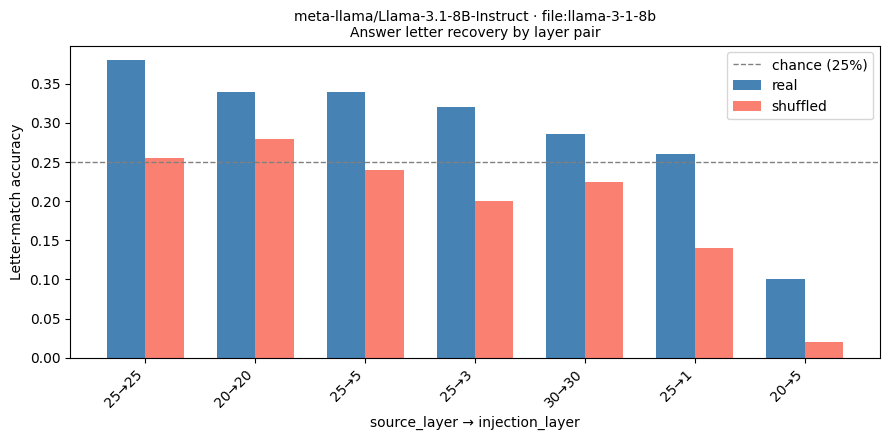

In [11]:
# ── Letter-match accuracy by layer pair ───────────────────────────────
# Which (source_layer → injection_layer) combinations carry the most answer signal?

if len(sub):
    import matplotlib.pyplot as plt

    real_sub = sub[sub["condition"] == "real"].copy()
    real_sub["layer_pair"] = (
        real_sub["source_layer"].astype(str) + "→" + real_sub["injection_layer"].astype(str)
    )

    layer_acc = (
        real_sub.groupby("layer_pair", as_index=False)
        .agg(
            letter_acc=("matches_source_letter", "mean"),
            has_letter=("predicted_letter", lambda s: s.notna().mean()),
            n=("question_id", "count"),
        )
        .sort_values("letter_acc", ascending=False)
        .round(4)
    )

    print(f"=== Letter-match accuracy by layer pair (real condition) · {PLOT_MODEL_LABEL} ===")
    print(layer_acc.to_string(index=False))
    print()
    display(layer_acc)

    # Also show shuffled for comparison
    shuf_sub = sub[sub["condition"] == "shuffled"].copy()
    shuf_sub["layer_pair"] = (
        shuf_sub["source_layer"].astype(str) + "→" + shuf_sub["injection_layer"].astype(str)
    )
    shuf_acc = shuf_sub.groupby("layer_pair", as_index=False).agg(
        letter_acc_shuffled=("matches_source_letter", "mean"),
    ).round(4)

    merged = layer_acc.merge(shuf_acc, on="layer_pair", how="left")
    merged["lift_over_shuffled"] = (merged["letter_acc"] - merged["letter_acc_shuffled"]).round(4)

    print(f"\n=== Real vs shuffled by layer pair · {PLOT_MODEL_LABEL} ===")
    print(merged[["layer_pair", "letter_acc", "letter_acc_shuffled", "lift_over_shuffled", "n"]].to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = range(len(merged))
    width = 0.35
    ax.bar([i - width/2 for i in x], merged["letter_acc"], width, label="real", color="steelblue")
    ax.bar([i + width/2 for i in x], merged["letter_acc_shuffled"], width, label="shuffled", color="salmon")
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="chance (25%)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(merged["layer_pair"], rotation=45, ha="right")
    ax.set_ylabel("Letter-match accuracy")
    ax.set_xlabel("source_layer → injection_layer")
    ax.set_title(f"{PLOT_MODEL_LABEL}\nAnswer letter recovery by layer pair", fontsize=10)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No data.")

=== Letter-match: source × reporter (real, has_letter) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===
      source_persona     reporter_persona  letter_acc   n pair_type
persona_conservative    neutral_evaluator      0.4437 142     cross
persona_conservative persona_conservative      0.4437 142      same
persona_conservative  persona_progressive      0.4437 142     cross
 persona_progressive    neutral_evaluator      0.3089 123     cross
 persona_progressive persona_conservative      0.3089 123     cross
 persona_progressive  persona_progressive      0.3089 123      same

Same-persona vs cross-persona (mean across pairs):
           mean_acc  total_n
pair_type                   
cross        0.3763      530
same         0.3763      265



,mean_acc,total_n
pair_type,,
cross,0.3763,530
same,0.3763,265


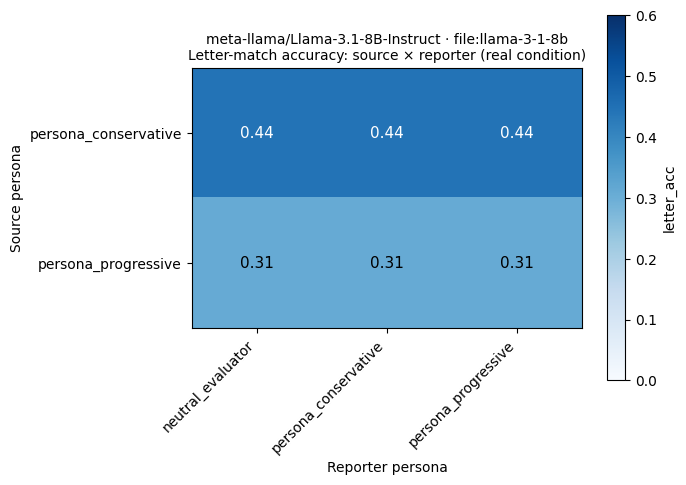


=== Same table for shuffled condition (control) ===
      source_persona     reporter_persona  letter_acc_shuffled
persona_conservative    neutral_evaluator               0.1831
persona_conservative persona_conservative               0.1831
persona_conservative  persona_progressive               0.1831
 persona_progressive    neutral_evaluator               0.3361
 persona_progressive persona_conservative               0.3415
 persona_progressive  persona_progressive               0.3415


In [12]:
# ── Letter-match by source_persona × reporter_persona ─────────────────
# Does a conservative reporter decode a conservative source's answer better
# than a progressive source's answer?  This is the core PSM question:
# if personas change computation, same-persona pairs should show higher accuracy.

if len(sub):
    import matplotlib.pyplot as plt

    real_sub = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()].copy()

    cross = (
        real_sub.groupby(["source_persona", "reporter_persona"], as_index=False)
        .agg(
            letter_acc=("matches_source_letter", "mean"),
            n=("question_id", "count"),
        )
        .round(4)
    )

    # Add same/cross persona label
    cross["pair_type"] = cross.apply(
        lambda r: "same" if r["source_persona"] == r["reporter_persona"] else "cross",
        axis=1,
    )

    print(f"=== Letter-match: source × reporter (real, has_letter) · {PLOT_MODEL_LABEL} ===")
    print(cross.to_string(index=False))
    print()

    # Aggregate same vs cross
    same_cross = cross.groupby("pair_type").agg(
        mean_acc=("letter_acc", "mean"),
        total_n=("n", "sum"),
    ).round(4)
    print("Same-persona vs cross-persona (mean across pairs):")
    print(same_cross.to_string())
    print()
    display(same_cross)

    # Heatmap
    piv = cross.pivot(index="source_persona", columns="reporter_persona", values="letter_acc")
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(piv.values, cmap="Blues", vmin=0, vmax=max(0.6, piv.values.max()))
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel("Reporter persona")
    ax.set_ylabel("Source persona")
    ax.set_title(
        f"{PLOT_MODEL_LABEL}\nLetter-match accuracy: source × reporter (real condition)",
        fontsize=10,
    )
    # Annotate cells
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            val = piv.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.4 else "black", fontsize=11)
    fig.colorbar(im, ax=ax, label="letter_acc")
    fig.tight_layout()
    plt.show()

    # Also show shuffled for comparison
    shuf_real = sub[(sub["condition"] == "shuffled") & sub["predicted_letter"].notna()].copy()
    if len(shuf_real):
        shuf_cross = (
            shuf_real.groupby(["source_persona", "reporter_persona"], as_index=False)
            .agg(letter_acc_shuffled=("matches_source_letter", "mean"))
            .round(4)
        )
        print(f"\n=== Same table for shuffled condition (control) ===")
        print(shuf_cross.to_string(index=False))
else:
    print("No data.")

## Answer & prediction distributions

The source × reporter heatmap shows the **reporter persona has no effect** — each row is flat (same accuracy regardless of reporter). But the **source persona matters**: conservative ~44%, progressive ~26%.

Before concluding this is a persona effect, we need to check for confounds:
- Does the model have a **letter bias** in its predictions (e.g. always predicting A)?
- Do the two personas have different **answer distributions** (e.g. conservative answers A more)?
- If the model's prediction bias happens to align with one persona's answer distribution, that alone could explain the accuracy gap.

=== Bias-corrected letter-match · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===

  real:
    observed accuracy = 0.381
    expected (bias-only, independent) = 0.246
    lift above bias = +0.135
    → REAL SIGNAL

  shuffled:
    observed accuracy = 0.256
    expected (bias-only, independent) = 0.235
    lift above bias = +0.020
    → REAL SIGNAL

--- Per source_persona (real condition) ---

  persona_conservative: observed=0.444  bias_expected=0.269  lift=+0.175
  persona_progressive: observed=0.309  bias_expected=0.231  lift=+0.078

=== Confusion matrix (real, has_letter) · meta-llama/Llama-3.1-8B-Instruct · file:llama-3-1-8b ===

predicted_letter        A    B   C    D  All
source_direct_answer                        
A                     165   30   0   15  210
B                      33   78  24   36  171
C                     102   69  39   36  246
D                      51   78  18   21  168
All                   351  255  81  108  795



predicted_letter,A,B,C,D,All
source_direct_answer,,,,,
A,165,30,0,15,210
B,33,78,24,36,171
C,102,69,39,36,246
D,51,78,18,21,168
All,351,255,81,108,795


Row-normalized (P(predicted | source_answer)):
predicted_letter          A      B      C      D
source_direct_answer                            
A                     0.786  0.143  0.000  0.071
B                     0.193  0.456  0.140  0.211
C                     0.415  0.280  0.159  0.146
D                     0.304  0.464  0.107  0.125



predicted_letter,A,B,C,D
source_direct_answer,,,,
A,0.786,0.143,0.000,0.071
B,0.193,0.456,0.140,0.211
C,0.415,0.280,0.159,0.146
D,0.304,0.464,0.107,0.125


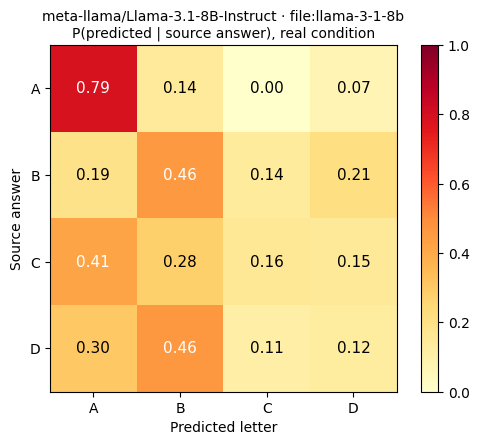

In [14]:
# ── Bias-corrected accuracy: is the match real or just distribution overlap? ──
#
# If the model always predicts A, and the source answers A 50% of the time,
# you'd get 50% "accuracy" from bias alone.  We compute the expected accuracy
# under independence (prediction and answer distributions uncorrelated) and
# compare to the observed accuracy.

if len(sub):
    print(f"=== Bias-corrected letter-match · {PLOT_MODEL_LABEL} ===\n")

    for cond in ["real", "shuffled"]:
        cond_sub = sub[(sub["condition"] == cond) & sub["predicted_letter"].notna()]
        if len(cond_sub) == 0:
            continue

        labels = ["A", "B", "C", "D"]
        # Marginal distributions (as fractions)
        src_counts = cond_sub["source_direct_answer"].value_counts().reindex(labels, fill_value=0)
        pred_counts = cond_sub["predicted_letter"].value_counts().reindex(labels, fill_value=0)
        n = len(cond_sub)
        src_frac = src_counts / n
        pred_frac = pred_counts / n

        # Expected accuracy under independence: sum(P(src=X) * P(pred=X)) for X in ABCD
        expected_acc = sum(src_frac[l] * pred_frac[l] for l in labels)
        observed_acc = cond_sub["matches_source_letter"].mean()
        lift = observed_acc - expected_acc

        print(f"  {cond}:")
        print(f"    observed accuracy = {observed_acc:.3f}")
        print(f"    expected (bias-only, independent) = {expected_acc:.3f}")
        print(f"    lift above bias = {lift:+.3f}")
        print(f"    → {'REAL SIGNAL' if lift > 0.02 else 'mostly bias' if lift > 0 else 'below bias'}")
        print()

    # Per source_persona
    print(f"--- Per source_persona (real condition) ---\n")
    real_with_letter = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()]
    for sp_name, sp_group in real_with_letter.groupby("source_persona"):
        src_counts = sp_group["source_direct_answer"].value_counts().reindex(labels, fill_value=0)
        pred_counts = sp_group["predicted_letter"].value_counts().reindex(labels, fill_value=0)
        n = len(sp_group)
        src_frac = src_counts / n
        pred_frac = pred_counts / n
        expected_acc = sum(src_frac[l] * pred_frac[l] for l in labels)
        observed_acc = sp_group["matches_source_letter"].mean()
        lift = observed_acc - expected_acc
        print(f"  {sp_name}: observed={observed_acc:.3f}  bias_expected={expected_acc:.3f}  lift={lift:+.3f}")
    print()

    # Confusion matrix
    print(f"=== Confusion matrix (real, has_letter) · {PLOT_MODEL_LABEL} ===\n")
    real_with_letter = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()].copy()
    confusion = pd.crosstab(
        real_with_letter["source_direct_answer"],
        real_with_letter["predicted_letter"],
        margins=True,
    )
    print(confusion.to_string())
    print()
    display(confusion)

    # Normalized confusion (row-wise: for each source answer, what fraction was predicted as each letter?)
    confusion_norm = pd.crosstab(
        real_with_letter["source_direct_answer"],
        real_with_letter["predicted_letter"],
        normalize="index",
    ).round(3)
    print("Row-normalized (P(predicted | source_answer)):")
    print(confusion_norm.to_string())
    print()
    display(confusion_norm)

    # Heatmap of normalized confusion
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(confusion_norm.values, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(confusion_norm.columns)))
    ax.set_xticklabels(confusion_norm.columns)
    ax.set_yticks(range(len(confusion_norm.index)))
    ax.set_yticklabels(confusion_norm.index)
    ax.set_xlabel("Predicted letter")
    ax.set_ylabel("Source answer")
    ax.set_title(f"{PLOT_MODEL_LABEL}\nP(predicted | source answer), real condition", fontsize=10)
    for i in range(len(confusion_norm.index)):
        for j in range(len(confusion_norm.columns)):
            val = confusion_norm.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.4 else "black", fontsize=11)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()
else:
    print("No data.")

### Interpretation guide

**Letter-match accuracy** is the primary metric for the identity prompt format. The pattern-echo output (`N -> N; ...`) is expected — it's the prompt design. What matters is whether answer letters leak through the echo and match the source's answer.

Key comparisons:
- **real vs chance (25%)**: Does the patched activation carry answer information at all?
- **real vs shuffled**: Is the information specific to this question, or generic?
- **same-persona vs cross-persona pairs**: Does the reporter decode better when it shares the source's persona? (PSM signal)
- **Layer pair variation**: Which extraction → injection layer combinations carry the most signal? Mid-to-late extraction layers typically work best.

### Next steps

- Try **wrong-persona, same-question** control (patches activation from a different persona answering the same question) to isolate persona-specific signal from content signal.
- Add **random noise** control (Gaussian, norm-matched) as a sanity check.
- For free-form experiments: switch to a descriptive template and use LLM-judge or embedding similarity for evaluation.